# Towards biologically plausible phosphene simulation for the differentiable optimization of visual thalamic prostheses

This notebook is the **bilateral** counterpart of `demo_simulator_lgn.ipynb`. It walks through the same seven sections, in the same order, with the same figures — but with an implant in **both** lateral geniculate nuclei rather than one, so the percept covers the whole visual field instead of half of it.

Everything that differs from the single-nucleus notebook follows from one config key:

```yaml
atlas:
  hemispheres: [left, right]
```

With `[left]` — the shipped default — `build_simulator` returns an `LGNPhospheneSimulator` covering the right hemifield, and the left half of every frame stays black. With both, it returns a **`BilateralLGNSimulator`**: one sub-simulator per nucleus, each with its own electrode array, its own leaky-integrator state and its own per-electrode thresholds, summed into one image. Stimulating one nucleus does not charge the other, which is what the tissue says.

Three practical consequences run through everything below:

- **`electrodes.n_electrodes` is per nucleus.** A bilateral build of the same config places that many on each side. `n_electrodes_by_hemisphere` overrides one side for an asymmetric implant.
- **Electrodes are numbered left nucleus first.** `electrode_slices` and `hemisphere_of_electrode` say which is which; every per-electrode vector — amplitudes in, brightness and sigmas out — uses that order.
- **Inclination now uses its whole range.** One nucleus spans (−90°, 90°), the other the rest. In the single-nucleus notebook, targets outside (−90°, 90°) had nowhere to go.

> **The right nucleus is the left one reflected, not a second dataset.** There is one reconstructed LGN in the world and it is a left one. `MirroredAtlas` reflects it across the midline — ML axis reversed, inclination `I → 180 − I`, i.e. visual-field `x → −x` — and assumes the two nuclei are mirror images. That is the textbook first approximation and nothing more: real left and right LGNs differ in volume and cell count, and no second atlas exists to say by how much. So **the left half of every percept below carries the right half's uncertainty plus the assumption of symmetry.** The provenance warning from the single-nucleus notebook applies unchanged on top of that: the current-spread constant is transplanted from macaque V1, the temporal dynamics and rheobase from human V1, the koniocellular receptive fields from owl monkey. Treat the pictures as a working model, not as measurements.

## 0. Imports

##### Import statements

In [1]:
import os
import sys
sys.path.append('./..')
import logging

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

import dynaphos
from dynaphos import utils
from dynaphos.utils import Map, get_data_kwargs, to_numpy
from dynaphos.image_processing import canny_processor, sobel_processor

import dynaphos_lgn
from dynaphos_lgn.bilateral import BilateralLGNSimulator
from dynaphos_lgn.build import build_simulator
from dynaphos_lgn.params import require

# The atlas and the build steps report what they are doing.
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

# The four .DAT files plus the cached JACOBIAN.npz. There is ONE cache
# however many nuclei are simulated: reflecting a Jacobian is
# re-indexing plus a sign pattern, so the right nucleus is derived from
# this fit rather than fitted again. If the files are not there,
# build_simulator falls back -- loudly -- to the synthetic stand-in
# atlas, which exercises the code but means nothing biologically.
ATLAS_DIR = '../data/Erwin_Atlas'

# Colours used throughout, so every figure names the nuclei the same way
HEMISPHERE_COLOURS = {'left': 'tab:blue', 'right': 'tab:red'}

##### Some plotting functions

In [2]:
def plot_fov(params, ax):
    """Plot a polar grid and visualize the field of view of simulation."""
    fov = params['run']['view_angle']
    org = params['run']['origin']

    # Plot the simulation FOV (square)
    x1, x2 = org[0]-fov//2, org[0] + fov//2
    y1, y2 = org[1]-fov//2, org[1] + fov//2
    ax.plot([x1,x1,x2,x2,x1], [y1,y2,y2,y1,y1], color='k')

    # Plot the radial lines
    for angle in np.linspace(-np.pi,np.pi,9) :
        r = []
        phi = []
        for radius in np.linspace(0,60,1000):
            r.append(radius)
            phi.append(angle)

        visual_field = Map(r = np.array(r), phi = np.array(phi))
        ax.plot(*visual_field.cartesian, 'k:',linewidth=.5)


    # Plot the concentric grid lines
    for radius in np.linspace(1,60,8):
        r = []
        phi = []
        for angle in np.linspace(-np.pi,np.pi,100):
            r.append(radius)
            phi.append(angle)

        visual_field = Map(r = np.array(r), phi = np.array(phi))
        ax.plot(*visual_field.cartesian, 'k:',linewidth=.5)

    ax.spines[['left', 'bottom']].set_position('center')
    ax.spines[['right', 'top']].set_visible(False)

    ticks = [-fov, -fov//2, 0, fov//2, fov]
    ax.set(xticks=ticks, yticks=ticks)
    ax.set_xlim(-1.1*fov, 1.1*fov)
    ax.set_ylim(-1.1*fov, 1.1*fov)
    ax.set_aspect('equal')


def plot_phosphene_locations(simulator, ax, params=None):
    """Phosphene positions, coloured by the nucleus that produces them.

    The bilateral counterpart of the single-nucleus notebook's
    `ax.plot(*phosphene_coords.cartesian, 'r.')`. Splitting by
    `electrode_slices` is the whole point of the figure: it shows that
    the two nuclei tile opposite halves of the field.
    """
    for name, span in simulator.electrode_slices.items():
        xy = simulator.vf_xy[span]
        ax.plot(xy[:, 0], xy[:, 1], '.', markersize=4,
                color=HEMISPHERE_COLOURS[name],
                label=f'{name} LGN ({span.stop - span.start})')
    if params is not None:
        plot_fov(params, ax)
    ax.legend(fontsize=7, loc='lower left')


def hemisphere_atlases(parts):
    """{hemisphere: atlas} out of whatever `build_simulator` returned.

    `parts` is flat for one nucleus and nested under `hemispheres` for
    two, so this works for either.
    """
    if 'hemispheres' in parts:
        return {name: p['atlas'] for name, p in parts['hemispheres'].items()}
    return {parts['atlas'].hemisphere: parts['atlas']}


def lateral_coordinates(atlas):
    """Lateral distance from the midline of every ML index, in mm.

    Goes through the atlas's own `index_to_horsley_clarke`, which is
    hemisphere-correct. Multiplying the index by the voxel size and
    adding the origin is NOT: the mirrored atlas reverses its ML axis,
    so that shortcut silently draws the right nucleus as the left one.
    """
    n_ml = atlas.atlas_shape[0]
    ml_mm, _, _ = atlas.index_to_horsley_clarke(np.arange(n_ml), 0, 0)
    return np.asarray(ml_mm, dtype=float)


def plot_lgn_section(params, atlas, ax, ap_mm, field='layer', side=None):
    """Plot one coronal section through an LGN atlas.

    `field='layer'` shows the four laminar codes in LAYERS.DAT,
    `field='eccentricity'` the retinotopy from ECC.DAT. `side` places
    the nucleus on the +1 or -1 side of the midline; the default puts
    the left nucleus left of it, so a bilateral figure reads
    anatomically rather than as two unrelated panels.

    Returns the artist, so a colorbar can be attached.
    """
    voxel_size = require(params, 'atlas.voxel_size_mm')
    if side is None:
        side = -1 if atlas.hemisphere == 'left' else +1

    _, dv_origin, ap_origin = atlas.index_to_horsley_clarke(0, 0, 0)
    k = int(round((ap_mm - ap_origin) / voxel_size))
    _, n_dv, _ = atlas.atlas_shape

    # Signed position of each ML row, then sorted ascending so imshow
    # can draw it against a normal axis.
    ml = side * lateral_coordinates(atlas)
    order = np.argsort(ml)
    half_voxel = voxel_size / 2
    extent = [dv_origin - half_voxel,
              dv_origin + (n_dv - 0.5) * voxel_size,
              ml[order][0] - half_voxel, ml[order][-1] + half_voxel]

    valid = atlas.valid[:, :, k]
    if field == 'layer':
        image = np.where(valid, atlas.layer[:, :, k], np.nan)
        artist = ax.imshow(image[order], origin='lower', extent=extent,
                           cmap='tab10', vmin=0.5, vmax=10.5,
                           interpolation='nearest')
    elif field == 'eccentricity':
        image = np.where(valid, atlas.eccentricity_deg[:, :, k], np.nan)
        artist = ax.imshow(image[order], origin='lower', extent=extent,
                           cmap='viridis', interpolation='nearest')
    else:
        raise ValueError(f"Unknown field {field!r}.")

    ax.set_aspect('equal')
    ax.set(xlabel='dorsal-ventral (mm)',
           ylabel='medial-lateral (mm, signed)')
    # Crop to the tissue rather than the (mostly empty) grid.
    rows, cols = np.nonzero(valid)
    if len(rows):
        pad = 10 * voxel_size
        ax.set_xlim(dv_origin + cols.min() * voxel_size - pad,
                    dv_origin + cols.max() * voxel_size + pad)
    return artist


def electrode_positions_mm(atlas, voxel_indices, side=None):
    """(n, 3) voxel indices -> signed (ml, dv, ap) mm, for plotting."""
    if side is None:
        side = -1 if atlas.hemisphere == 'left' else +1
    ml, dv, ap = atlas.index_to_horsley_clarke(
        *np.asarray(voxel_indices).T)
    return np.stack([side * np.asarray(ml), np.asarray(dv),
                     np.asarray(ap)], axis=-1)

## 1. Basic usage

#### Initialization
The simulator is initialized using a configuration file (params_lgn.yaml) and the atlas. As in the single-nucleus notebook it is *not* given a map of phosphene coordinates: those are read out of the atlas at whichever voxels the electrodes occupy. The only new line is `atlas.hemispheres`, and it changes the **type** of what comes back — `build_simulator` returns a `BilateralLGNSimulator` as soon as more than one nucleus is asked for.

In [3]:
# Load the simulator configuration file (and adjust to preferences).
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds

# BOTH nuclei. This is the one line that separates this notebook from
# demo_simulator_lgn.ipynb; everything else follows from it.
params['atlas']['hemispheres'] = ['left', 'right']

# Keep the electrodes inside the rendered 16 deg frame. At 15 deg
# eccentricity, 130 of these 200 electrodes sit outside it and
# contribute nothing to the image. (The simulator warns when they
# do.) 6 deg also matches every other cell in this notebook.
params['electrodes']['max_eccentricity_deg'] = 6.0

In [4]:
# Get electrode locations (and with them, the phosphene coordinates).
#
# NOTE: n_electrodes is now PER NUCLEUS. 50 a side gives the same 100
# electrodes the single-nucleus notebook used, spread over twice the
# visual field.
params['electrodes']['n_electrodes'] = 100

## By default the electrodes are spread evenly in the VISUAL FIELD by
## farthest-point sampling over atlas voxels, independently in each
## nucleus. To place them yourself, pass voxel_indices= or
## visual_field_targets= instead; both are shown in section 2.

In [5]:
# Initialize simulator
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)

atlases = hemisphere_atlases(parts)           # kept for section 2
n_phosphenes = simulator.num_phosphenes
phosphene_coords = simulator.visual_field     # <- an output, not an input

print(simulator.describe())

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
WARNING 1 electrodes have no usable magnification and will render with NaN size.
WARNING 68 of 100 electrodes lie outside the rendered 16.0 deg field of view and will contribute nothing to the image (their recruitment is still computed). Widen run.view_angle or lower electrodes.max_eccentricity_deg to see them.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
WARNING 62 of 100 electrodes lie outside the rendered 16.0 deg field of view and will contribute nothing to the image (their recruitment is still computed). Widen run.view_angle or lower electrodes.max_eccentricity_deg to see them.


BilateralLGNSimulator: 200 electrodes over 2 nuclei

[left LGN] electrodes 0-99
LGNElectrodeArray: 100 electrodes
  nucleus           : left LGN -> right hemifield
  eccentricity      : 0.90 - 15.00 deg
  I_max             : 100.0 uA
  spread radius     : 385 um nominal, 584 um gathered
  candidates        : 6667 per electrode (stride 2, each standing for 8 voxels)
  scatter points    : 512
  render mode       : 46 ellipse, 54 scatter
Electrode confidence flags (100 electrodes):
     1 / 100  central-1 deg, isotropic by construction
    54 / 100  Jacobian unreliable beyond its fit neighbourhood
   100 / 100  footprint touches placeholder/sentinel voxels
    37 / 100  footprint spans both magno and parvo tissue
     0 / 100  sized by scalar magnification (forced circular)

[right LGN] electrodes 100-199
LGNElectrodeArray: 100 electrodes
  nucleus           : right LGN -> left hemifield, mirrored from the published left atlas
  eccentricity      : 0.10 - 15.00 deg
  I_max             : 1

#### Simulation
Each frame of simulation, the simulator is called using a vector that specifies the stimulation amplitude of each electrode. That vector spans **both** nuclei, left first. The simulator keeps track of the stimulation history — one history per nucleus — and can be reset to erase it.

In [6]:
# Stimulation amplitude
amplitude = 100.e-6 # Ampere (default 100uA)

# Stimulation vector, over both nuclei (left electrodes first)
stim = amplitude * torch.ones(n_phosphenes) # (All electrodes are activated)

# Reset and call the simulator
simulator.reset()
phosphenes = simulator(stim)

print(f'{n_phosphenes} electrodes: '
      + ', '.join(f'{name} {span.start}-{span.stop - 1}'
                  for name, span in simulator.electrode_slices.items()))

200 electrodes: left 0-99, right 100-199


#### Visualization
The output of the simulator is an image (as torch tensor) that represents the visual experience of the implant user — now over the whole field rather than one half of it.

Text(0.5, 1.0, 'Simulated phosphenes')

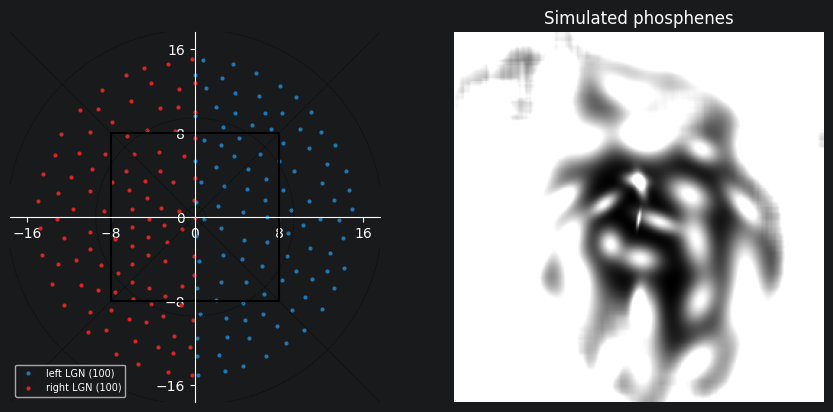

In [7]:
# Visualize
fig, axs = plt.subplots(1,2, figsize=(10.5,5))

# Plot the phosphene locations in the visual field, by nucleus
plot_phosphene_locations(simulator, axs[0], params)

# Plot the simulated phosphene image
axs[1].imshow(phosphenes, cmap='gray', origin='lower') # (origin is lower left)
axs[1].axis('off')
axs[1].set_title('Simulated phosphenes')

Compare that left panel with the single-nucleus notebook's: the right half is the same map, and the left half is its mirror image, produced by a second array in the reflected nucleus.

**Both halves of the field are now covered**, which is what the exercise was for. Two caveats carry over unchanged, and one is new.

**The phosphenes still merge into one mass.** At 100 µA a phosphene here has σ ≈ 0.8°, while 50 electrodes per nucleus inside the 6° window sit roughly a degree apart, so neighbours overlap heavily. Phosphene size is the *least* certain quantity in this model — K = 675 µA/mm² is transplanted from macaque V1 and unvalidated for LGN, and the resulting sizes run 4–6× larger than the Vurro et al. (2014) cross-reference. Read the usable electrode count as a property of the current parameters, not as a claim about the LGN.

**Phosphenes are ellipses, not discs**, because the recruitment sigma in millimetres of tissue is stretched by the *two* principal magnifications of the atlas's local Jacobian.

**New: the two halves are not statistically independent.** They are the same tissue reflected, so a feature of the left atlas's reconstruction — a tear, a sparsely sampled sector, the ±135° placeholder — appears in both halves of every percept, mirrored. Where the single-nucleus model was silent about the left hemifield, this one is confidently symmetric, and that confidence is an assumption rather than a measurement.

#### A closer look: phosphene shape, either side of the meridian
Dropping to 12 electrodes per nucleus separates them. Because reflection is an orthogonal map on both sides of the Jacobian, it leaves **both principal magnifications untouched** — so a phosphene and its mirror image are the same size and the same shape, with the ellipse's orientation reflected. The cell below checks exactly that against the simulator's own numbers.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Phosphene sigma at 100 uA, by nucleus (median over electrodes):
  left  major 0.89 deg   minor 0.57 deg   elongation 1.72x
  right major 0.87 deg   minor 0.53 deg   elongation 1.68x


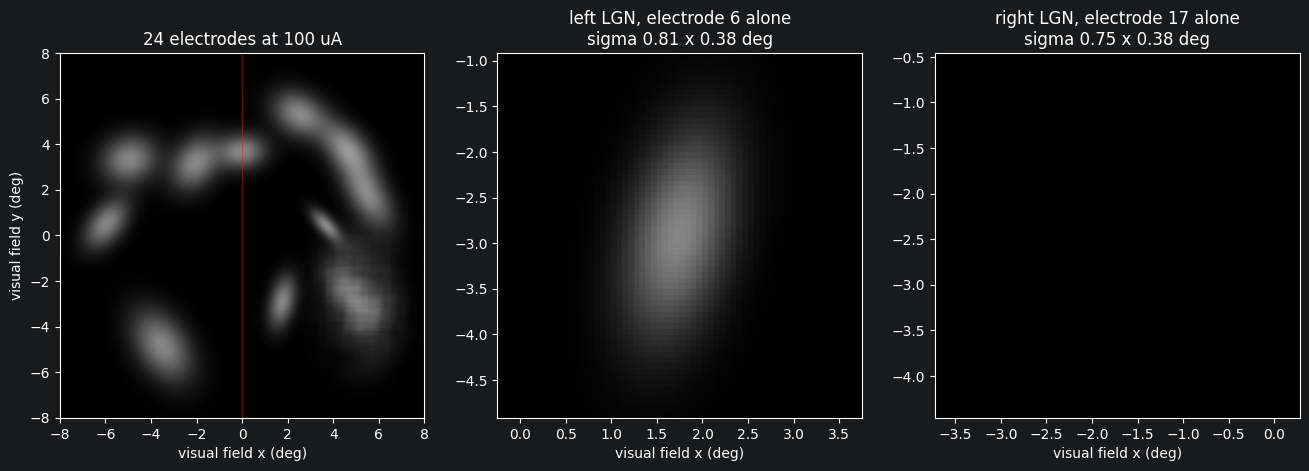

In [8]:
# Same config, fewer electrodes
params_small = utils.load_params('../config/params_lgn.yaml')
params_small['atlas']['hemispheres'] = ['left', 'right']
params_small['electrodes']['max_eccentricity_deg'] = 6.0
params_small['electrodes']['n_electrodes'] = 12      # per nucleus
simulator_small, _ = build_simulator(params_small, atlas_dir=ATLAS_DIR)

simulator_small.reset()
phosphenes_small = simulator_small(
    100.e-6 * torch.ones(simulator_small.num_phosphenes))

half = params_small['run']['view_angle'] / 2
extent = [-half, half, -half, half]

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(phosphenes_small, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
axs[0].axvline(0, color='tab:red', lw=0.8, alpha=0.5)
axs[0].set(xlabel='visual field x (deg)', ylabel='visual field y (deg)',
           title=f'{simulator_small.num_phosphenes} electrodes at 100 uA')

# The most isolated electrode in each nucleus, so one phosphene from
# each is unobstructed.
xy = simulator_small.vf_xy
distance = np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=-1)
np.fill_diagonal(distance, np.inf)
major, minor = simulator_small.phosphene_sigma_deg(100.)

for ax, (name, span) in zip(axs[1:], simulator_small.electrode_slices.items()):
    within = np.arange(span.start, span.stop)
    isolated = int(within[distance[span].min(axis=1).argmax()])
    cx, cy = xy[isolated]

    one_electrode = torch.zeros(simulator_small.num_phosphenes)
    one_electrode[isolated] = 100.e-6
    simulator_small.reset()
    single = simulator_small(one_electrode)

    ax.imshow(single, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
    ax.set_xlim(cx - 2, cx + 2)
    ax.set_ylim(cy - 2, cy + 2)
    ax.set(xlabel='visual field x (deg)',
           title=f'{name} LGN, electrode {isolated} alone\n'
                 f'sigma {major[isolated]:.2f} x {minor[isolated]:.2f} deg')

print('Phosphene sigma at 100 uA, by nucleus (median over electrodes):')
for name, span in simulator_small.electrode_slices.items():
    print(f'  {name:<5} major {np.nanmedian(major[span]):.2f} deg   '
          f'minor {np.nanmedian(minor[span]):.2f} deg   '
          f'elongation {np.nanmedian(major[span] / minor[span]):.2f}x')

#### Does lowering the current separate them?

Phosphene size is set by the current, so the obvious lever on the merging above is amplitude. The sweep below renders the same 50-per-nucleus array at several amplitudes and puts a number on "merged" rather than leaving it to the eye.

The criterion is **Sparrow's**: two equal Gaussians a distance `d` apart stop showing a dip between them — stop being two things — once `d < 2σ`. So an electrode is resolvable from its nearest neighbour when

```
nearest-neighbour spacing  >  2 × sigma
```

and the bottom panel plots σ against *half* the median spacing, which is where that line is crossed. σ_major is used for the strict version, since phosphenes here are ellipses and the long axis is what merges first.

Two things move in opposite directions as the current drops, which is the whole tension: phosphenes shrink and separate, but more of them fall below their detection threshold and vanish. The table reports both, so the trade is visible.

Edit `AMPLITUDES_UA` to taste. One constraint: `electrodes.max_current_ua` (100 µA here) is the largest current the precomputed candidate neighbourhood was sized for, so going above it silently truncates the recruited footprint. Raise that config value and rebuild rather than just passing more current — the cell asserts this rather than letting it pass.

    uA  sigma_maj  sigma_min  spacing/2sigma  resolvable  detected
    30      0.94d      0.49d            0.88         42%       18%
    40      1.09d      0.57d            0.76         34%       48%
    45      1.16d      0.60d            0.72         32%       58%
    50      1.22d      0.63d            0.68         29%       74%
    70      1.44d      0.75d            0.58         20%       98%
   100      1.72d      0.90d            0.48         12%      100%

Median centre-to-centre spacing: 1.73 deg (200 electrodes over both nuclei).
"resolvable" = share of electrodes whose nearest neighbour is more than 2 sigma away.
"detected"   = share with p(detect) > 0.5 at that amplitude.


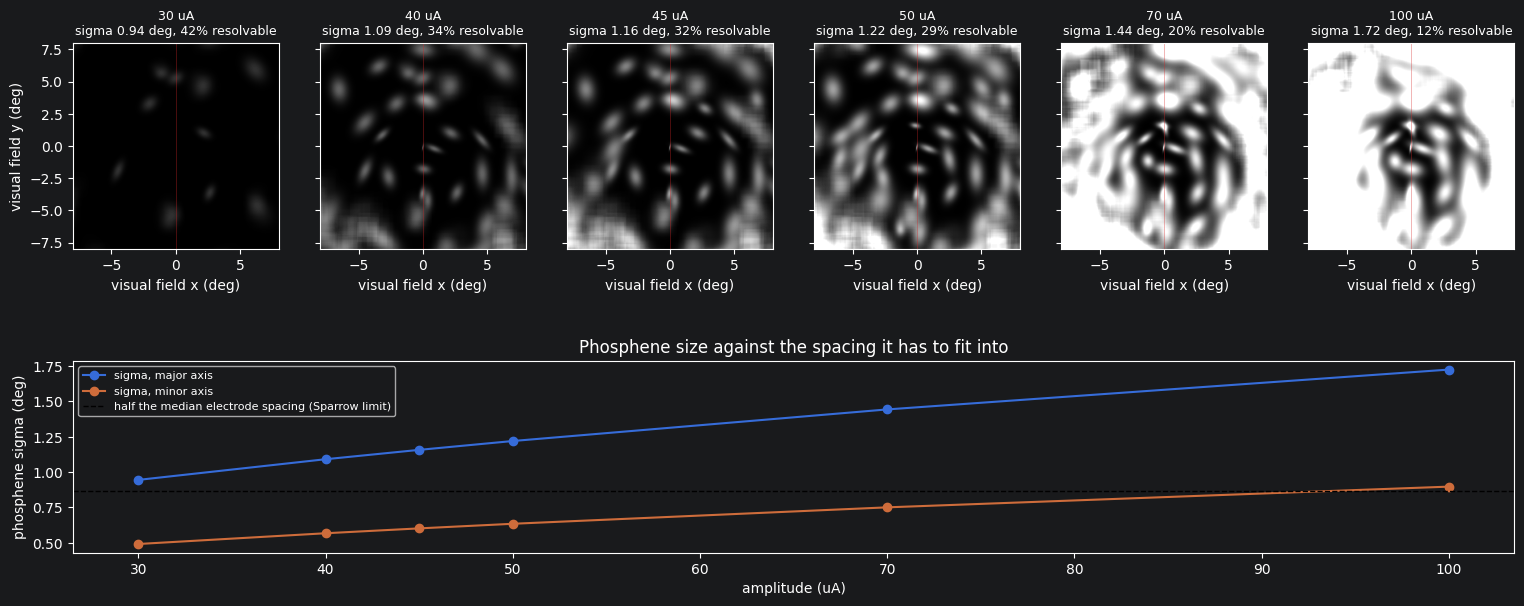

In [9]:
# ---- EDIT THIS ------------------------------------------------------
AMPLITUDES_UA = [30., 40., 45., 50., 70., 100.]
# ---------------------------------------------------------------------

max_current = params['electrodes']['max_current_ua']
assert max(AMPLITUDES_UA) <= max_current, (
    f'{max(AMPLITUDES_UA)} uA exceeds electrodes.max_current_ua '
    f'({max_current} uA). The candidate neighbourhood is sized once, at '
    f'setup, from that value -- beyond it the recruited footprint is '
    f'truncated rather than grown. Raise the config value and rebuild.')

half = params['run']['view_angle'] / 2
extent = [-half, half, -half, half]

# Centre-to-centre spacing is pure geometry: fixed by where the
# electrodes are, and unchanged by how hard they are driven.
centres = simulator.vf_xy
separation = np.linalg.norm(centres[:, None, :] - centres[None, :, :],
                            axis=-1)
np.fill_diagonal(separation, np.inf)
nn_spacing = separation.min(axis=1)

fig = plt.figure(figsize=(3.1 * len(AMPLITUDES_UA), 7.4))
grid = fig.add_gridspec(2, len(AMPLITUDES_UA), height_ratios=[1.7, 1])

rows, median_major, median_minor = [], [], []
for i, amplitude_ua in enumerate(AMPLITUDES_UA):
    simulator.reset()
    image = simulator(amplitude_ua * 1e-6 * torch.ones(n_phosphenes))

    major, minor = simulator.phosphene_sigma_deg(amplitude_ua)
    detected = to_numpy(simulator.get_state()[
        'detection_probability']).ravel()
    resolvable = nn_spacing > 2 * major          # Sparrow
    rows.append((amplitude_ua, np.nanmedian(major), np.nanmedian(minor),
                 np.nanmedian(nn_spacing / (2 * major)),
                 100 * np.nanmean(resolvable), 100 * np.mean(detected > 0.5)))
    median_major.append(np.nanmedian(major))
    median_minor.append(np.nanmedian(minor))

    ax = fig.add_subplot(grid[0, i])
    ax.imshow(image, cmap='gray', origin='lower', vmin=0, vmax=1,
              extent=extent)
    ax.axvline(0, color='tab:red', lw=0.6, alpha=0.4)
    ax.set_title(f'{amplitude_ua:.0f} uA\nsigma {rows[-1][1]:.2f} deg, '
                 f'{rows[-1][4]:.0f}% resolvable', fontsize=9)
    ax.set_xlabel('visual field x (deg)')
    if i:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('visual field y (deg)')

ax = fig.add_subplot(grid[1, :])
ax.plot(AMPLITUDES_UA, median_major, 'o-', label='sigma, major axis')
ax.plot(AMPLITUDES_UA, median_minor, 'o-', label='sigma, minor axis')
ax.axhline(np.median(nn_spacing) / 2, color='k', ls='--', lw=1.0,
           label='half the median electrode spacing (Sparrow limit)')
ax.set(xlabel='amplitude (uA)', ylabel='phosphene sigma (deg)',
       title='Phosphene size against the spacing it has to fit into')
ax.legend(fontsize=8)

print(f'{"uA":>6} {"sigma_maj":>10} {"sigma_min":>10} '
      f'{"spacing/2sigma":>15} {"resolvable":>11} {"detected":>9}')
for amplitude_ua, maj, mnr, ratio, res, det in rows:
    print(f'{amplitude_ua:6.0f} {maj:9.2f}d {mnr:9.2f}d '
          f'{ratio:15.2f} {res:10.0f}% {det:8.0f}%')
print(f'\nMedian centre-to-centre spacing: {np.median(nn_spacing):.2f} deg '
      f'({n_phosphenes} electrodes over both nuclei).')
print('"resolvable" = share of electrodes whose nearest neighbour is more '
      'than 2 sigma away.')
print('"detected"   = share with p(detect) > 0.5 at that amplitude.')

So: **yes at the shipped 100 µA, no if you turn the current down** — but not for free.

Reading the default sweep, with 50 electrodes a nucleus about 1.0° apart:

- σ_major crosses half the spacing at roughly **45 µA**. Above that the median phosphene is wider than the gap to its neighbour and the array reads as one mass; below it, most phosphenes stand apart.
- But brightness collapses over the same range. With the soft threshold pinned above, the percept fades rather than emptying: at 30 µA nothing clears p(detect) = 0.5 and the whole field is a dim haze, at 40 µA about a fifth of electrodes clear it. The window where most phosphenes are *both* clearly visible and separate is narrow.
- That fade is the detection model talking, not the size model. Set `params['thresholding']['soft_threshold'] = False` in the cell above and the same sweep goes sparse-but-crisp instead — fewer phosphenes, each at full brightness — because the hard gate is all-or-nothing. The resolvability column does not move either way: σ does not depend on the threshold.
- The minor axis crosses much lower, which is why the intermediate panels look like a field of streaks: phosphenes separate across their short axis while still merging along their long one.

Three caveats before reading any of that as a specification.

**The size model is the least certain thing here.** σ comes from the recruitment radius via K = 675 µA/mm², transplanted from macaque V1 and never validated for LGN, and the resulting sizes run 4–6× larger than the Vurro et al. (2014) cross-reference. If K is wrong by that factor, the whole σ curve shifts and the crossing amplitude moves with it. The *shape* of the trade-off is more robust than the number on the x-axis.

**Amplitude is not the only lever, and it is the crudest.** Spacing is the other half of the ratio: the 12-per-nucleus array above separates at 100 µA, where this one does not. Pulse width and frequency move the charge per second without moving σ (section 3), so they trade brightness against detection independently of size.

**Sparrow's criterion is about two isolated Gaussians.** Real electrodes here have several neighbours, unequal brightness and elliptical, differently-oriented profiles, so "resolvable" is a summary statistic and not a psychophysical claim. Nothing in this model has been checked against a discrimination experiment, because for LGN there is none.

## 2. Atlas models
Instead of letting the simulator spread the electrodes for you, it can be initialized from a list of electrode locations **in the tissue**. Positions are given in Horsley-Clarke stereotaxic millimetres, converted to atlas voxel indices, and the atlas supplies the phosphene location for each.

Two things change with two nuclei. `voxel_indices` is now a **dict keyed by hemisphere**, because an index alone does not say which nucleus it belongs to — passing a bare array raises rather than guessing. And `ml_mm` is *lateral distance from the midline*, positive in both nuclei, so the same grid coordinates address mirror-image tissue on each side. That is deliberately what is done below: one implant design, placed identically in both nuclei.

In [10]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited

left_atlas = atlases['left']

# Place a square electrode grid in the tissue (Horsley-Clarke mm).
# Centre it on the atlas's own foveal representation rather than on
# hardcoded coordinates, so this also works against the synthetic atlas.
foveal = np.argwhere(left_atlas.valid & ~left_atlas.is_ipsi_sentinel()
                     & (left_atlas.eccentricity_deg <= 5))
center_ml, center_dv, center_ap = left_atlas.index_to_horsley_clarke(
    *foveal.mean(axis=0))

# The grid lies in the medial-lateral / dorsal-ventral plane at a fixed
# anterior-posterior depth, i.e. in the plane the laminae curve in, so
# the coronal sections below show it face-on.
pitch = 0.4                                     # mm between electrodes
offsets = (np.arange(6) - 2.5) * pitch          # a 6 x 6 grid
ml, dv = np.meshgrid(center_ml + offsets, center_dv + offsets, indexing='ij')
ap = np.full(ml.size, center_ap)
print(f'Grid centre: ML {center_ml:.2f}, DV {center_dv:.2f}, '
      f'AP {center_ap:.2f} mm; {pitch * 1e3:.0f} um pitch.')

# The SAME millimetre coordinates in both nuclei: ml_mm is lateral
# distance from the midline, so each atlas resolves it to its own
# mirror-image voxel.
voxels = {}
for name, atlas in atlases.items():
    index = np.stack(atlas.horsley_clarke_to_index(
        ml.ravel(), dv.ravel(), ap, hemisphere=name), axis=-1)

    # Keep only the electrodes that landed in reconstructed,
    # non-placeholder tissue. A real implant has the same problem; the
    # atlas just makes it visible beforehand.
    on_tissue = (atlas.valid[tuple(index.T)]
                 & ~atlas.is_ipsi_sentinel(
                     atlas.inclination[tuple(index.T)]))
    print(f'{name:<5} LGN: {on_tissue.sum()} of {on_tissue.size} grid '
          f'positions are on usable tissue.')
    voxels[name] = index[on_tissue]

# Initialize simulator from the tissue coordinates, per nucleus
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR,
                                   voxel_indices=voxels)
n_phosphenes = simulator.num_phosphenes
phosphene_coords = simulator.visual_field

# Reset and call the simulator
stim = 80.e-6 * torch.ones(n_phosphenes) # (All electrodes are activated)
simulator.reset()
phosphenes = simulator(stim)

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.


Grid centre: ML 12.62, DV 3.72, AP 5.63 mm; 400 um pitch.
left  LGN: 34 of 36 grid positions are on usable tissue.
right LGN: 34 of 36 grid positions are on usable tissue.


INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Text(0.5, 1.0, 'Simulated phosphenes')

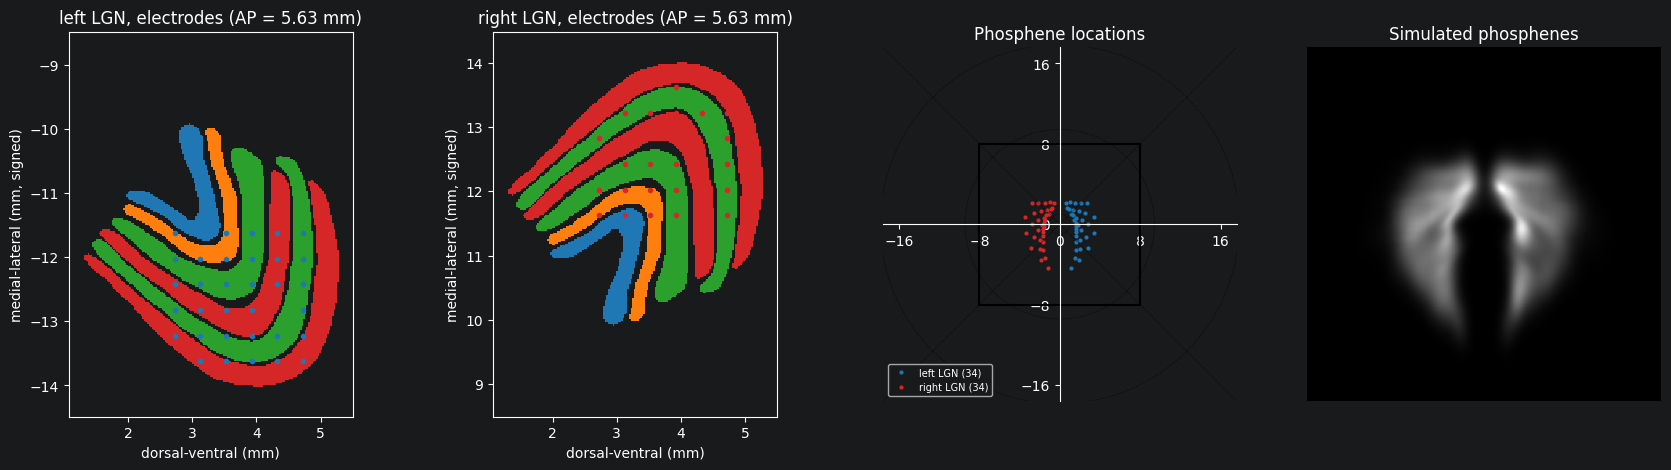

In [11]:
# Visualize
fig, axs = plt.subplots(1, 4, figsize=(21, 5))

# Plot each nucleus on a coronal section, placed either side of the
# midline so the pair reads anatomically
for ax, (name, atlas) in zip(axs[:2], atlases.items()):
    plot_lgn_section(params, atlas, ax, ap_mm=center_ap)
    positions = electrode_positions_mm(atlas, voxels[name])
    ax.plot(positions[:, 1], positions[:, 0], '.',
            color=HEMISPHERE_COLOURS[name], markersize=6)
    ax.set_title(f'{name} LGN, electrodes (AP = {center_ap:.2f} mm)')

# Plot the phosphene locations in the visual field
plot_phosphene_locations(simulator, axs[2], params)
axs[2].set_title('Phosphene locations')

# Plot the simulated phosphene image
axs[3].imshow(phosphenes, cmap='gray', origin='lower') # (origin is lower left)
axs[3].axis('off')
axs[3].set_title('Simulated phosphenes')

The coloured bands in the two left panels are the four laminar codes in `LAYERS.DAT` — magnocellular 1–2 and parvocellular 3–4, split by eye of origin, which is what makes six bands in section. The two nuclei are drawn either side of the midline, and they are exact mirror images because that is how the right one is built.

A regular grid in tissue is emphatically *not* regular in the visual field: the same 400 µm pitch spans a fraction of a degree near the foveal representation and several degrees away from it, the grid shears and folds, and an electrode crossing a laminar boundary jumps to the other eye's map of nearly the same point. With two nuclei that distortion is now visible twice, reflected — which is a useful way to see it, and also a reminder that the second copy is not independent evidence.

#### The inverse: asking for phosphenes at given visual-field positions
`visual_field_targets` runs the lookup the other way, putting each electrode in the tissue nearest a requested percept location. With two nuclei, each target is **routed by the sign of `x = E·cos(I)`** to the nucleus whose hemifield contains it; targets on the vertical meridian go to the left nucleus, arbitrarily but consistently. Ask for a hemifield with no targets in it and the build raises rather than handing back an empty array.

It is nearest-neighbour, not exact — `position_error_deg` reports how far off each one landed.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


             requested                    realised     miss
 left  ( 1.0 deg,  -75.0 deg)  ->  ( 1.0 deg,  -75.0 deg)   0.00 deg
 left  ( 2.0 deg,  -15.0 deg)  ->  ( 2.0 deg,  -15.0 deg)   0.00 deg
 left  ( 3.0 deg,  +45.0 deg)  ->  ( 3.0 deg,  +45.0 deg)   0.00 deg
right  ( 4.0 deg, +135.0 deg)  ->  ( 4.0 deg, +135.0 deg)   0.00 deg
right  ( 5.0 deg, +175.0 deg)  ->  ( 5.0 deg, +175.0 deg)   0.00 deg
right  ( 6.0 deg, -135.0 deg)  ->  ( 6.0 deg, -135.0 deg)   0.00 deg
right  ( 2.0 deg, -170.0 deg)  ->  ( 2.0 deg, -170.0 deg)   0.00 deg
right  ( 4.0 deg, +100.0 deg)  ->  ( 4.0 deg, +100.0 deg)   0.00 deg


Text(0.5, 1.0, 'Simulated phosphenes')

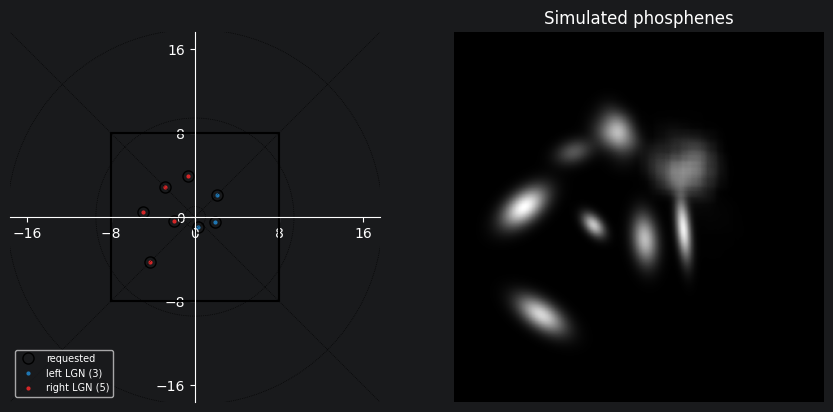

In [12]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited

# Requested phosphene locations (degrees). Inclination now spans the
# WHOLE range: with one nucleus it had to stay inside [-90, 90].
eccentricity = np.array([1., 2., 3., 4., 5., 6., 2., 4.])
inclination = np.array([-75., -15., 45., 135., 175., -135., -170., 100.])

simulator, parts = build_simulator(
    params, atlas_dir=ATLAS_DIR,
    visual_field_targets=(eccentricity, inclination))

# `parts` is nested per nucleus when both are built, and the targets
# were split between them, so report each nucleus against its own.
print(f'{"requested":>22}      {"realised":>22}     miss')
for name, span in simulator.electrode_slices.items():
    array = parts['hemispheres'][name]['electrode_array']
    x = eccentricity * np.cos(np.deg2rad(inclination))
    wanted = (x >= 0) if name == 'left' else (x < 0)
    for req_e, req_i, got_e, got_i, err in zip(
            eccentricity[wanted], inclination[wanted],
            array.eccentricity_deg, array.inclination_deg,
            array.position_error_deg):
        print(f'{name:>5}  ({req_e:4.1f} deg, {req_i:+6.1f} deg)  ->  '
              f'({got_e:4.1f} deg, {got_i:+6.1f} deg)   {err:.2f} deg')

simulator.reset()
phosphenes = simulator(80.e-6 * torch.ones(simulator.num_phosphenes))

fig, axs = plt.subplots(1, 2, figsize=(10.5, 5))
target = Map(r=eccentricity, phi=np.deg2rad(inclination))
axs[0].plot(*target.cartesian, 'ko', markersize=8, fillstyle='none',
            label='requested')
plot_phosphene_locations(simulator, axs[0], params)
axs[1].imshow(phosphenes, cmap='gray', origin='lower')
axs[1].axis('off')
axs[1].set_title('Simulated phosphenes')

### 3. Stimulation parameters
Instead of providing only the stimulation amplitudes, the other stimulation parameters (pulse width, frequency) can also be specified for each electrode. Those vectors span both nuclei too — or pass a scalar, which every nucleus receives.

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


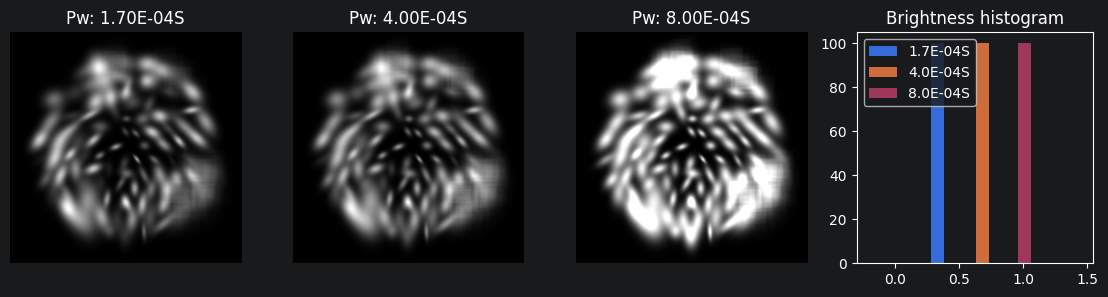

In [13]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
params['electrodes']['n_electrodes'] = 50        # per nucleus
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Plot phosphenes for different pulse widths
stim_amp = 35e-6 # A
freq = 300 # Hz
PWs = np.array([170.,400.,800.])*1e-6 # S

fig, axs = plt.subplots(1,4,figsize=(14,3))
for i,PW in enumerate(PWs):
    simulator.reset()
    stim = stim_amp*torch.ones(n_phosphenes)
    f = freq*torch.ones(n_phosphenes)
    pw = PW*torch.ones(n_phosphenes)
    img = simulator(stim,pw,f)
    axs[i].imshow(img,cmap='gray',origin='lower')
    axs[i].axis('off')
    axs[i].set_title(f'Pw: {PW:0.2E}S')

    # histogram of brightness, split by nucleus
    brightness = to_numpy(simulator.get_state()['brightness']).ravel()
    axs[3].hist(brightness, label=f'{PW:0.1E}S')

axs[3].legend()
axs[3].set_title('Brightness histogram')
plt.show()

The temporal dynamics, the rheobase and the brightness saturation curve behind this are inherited from the V1 model unchanged, and are identical in the two nuclei — nothing in the mirror touches them. There is no LGN or thalamic strength-duration data of any kind, so the pulse-width dependence shown here is transplanted, not measured; chronaxie in particular is a range rather than a number for thalamus (`default_stim.chronaxie_range_s`), because short pulses bias towards activating axons of passage.

The per-electrode thresholds *are* drawn separately per nucleus, from that nucleus's own generator, so the brightness histogram is not two identical halves.

## 4. Image preprocessing
In many experimental simulation paradigms, input images are preprocessed and used to create simulated phosphene images. This can be achieved with our simulator in three steps:
- image processing: natural image -> simplified image (e.g., edge detection.)
- stimulus sampling: simplified image -> stimulation vector (e.g., specific pixels in the edge image are mapped to specific electrode activations.)
- phosphene simulation: stimulation vector -> simulated phosphene representation (as readily demonstrated in above examples)

This is where two nuclei earn their keep: a centred image is no longer half thrown away.

#### Image processing - creating a simplified representation of the input image

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
WARNING 3 electrodes have no usable magnification and will render with NaN size.


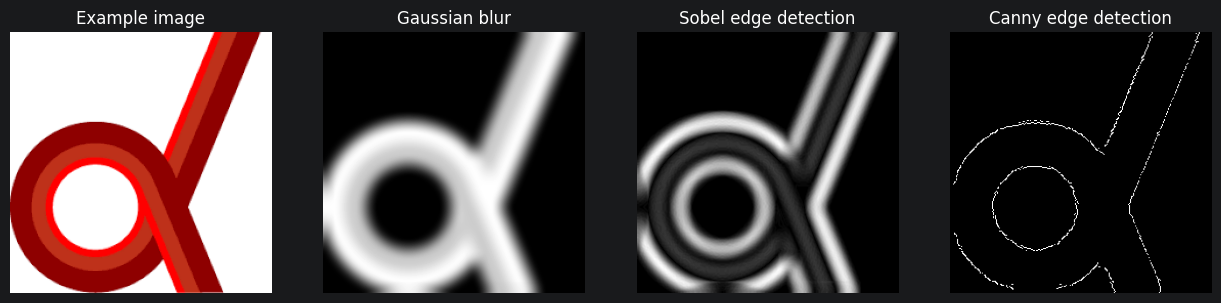

In [27]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['run']['fps'] = 10 # 10 fps -> a single frame represents 100 milliseconds
params['atlas']['hemispheres'] = ['left', 'right']
#params['thresholding']['soft_threshold'] = True   # pinned, not inherited
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
params['electrodes']['n_electrodes'] = 500       # per nucleus -> 1000 total
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Visualize different image processing examples
fig, axs = plt.subplots(1,4, figsize=(15.5,8))

# Example image
img = cv2.imread('../test/data/donders.png')
img = img[::-1] # Flip vertically (origin is lower-left)
axs[0].imshow(img[:,:,::-1], origin='lower') # (Invert color channels)
axs[0].set_title('Example image')

# General preprocessing
resolution = (256,256)
frame = cv2.resize(img, resolution)
img_gray = 255 - cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Gaussian blur
img_blur = cv2.GaussianBlur(img_gray, (21,21), 7)
axs[1].imshow(img_blur, cmap='gray', origin='lower')
axs[1].set_title('Gaussian blur')

# Sobel edge detection
img_sobel = sobel_processor(img_blur)
axs[2].imshow(img_sobel, cmap='gray', origin='lower')
axs[2].set_title('Sobel edge detection')

# Canny edge detection
img_canny = canny_processor(img_blur,threshold_low=70,threshold_high=100)
axs[3].imshow(img_canny, cmap='gray', origin='lower')
axs[3].set_title('Canny edge detection')

for ax in axs.flatten():
    ax.axis('off')

#### Stimulus sampling - mapping an image to stimulation vector
The inbuilt stimulus sampling method samples the pixel intensities at the phosphene locations to obtain a stimulation vector. By default, the pixel values of the sampled image are expected to represent the stimulation amplitude in Ampère.

By setting the rescale argument to True, the stimulus sampling method can be explicitly instructed to remap the pixels values: [0., 1.] or [0, 255] -> [0., *stimulus_scale*]. The *stimulus_scale* is specified in the simulator configuration file (100 microampere by default).

Each nucleus samples the **whole** image; because their electrodes sit in opposite hemifields, between them they read all of it, and the returned vector is the two halves concatenated.

The sampling region is `sampling.rf_cell_class` / `rf_form`'s `rc(E)` curve — in-project least-squares fits to Croner & Kaplan (1995) — used in degrees directly, with no tissue conversion. It depends on eccentricity only, so it is identical for an electrode and its mirror image.

In [28]:
##  Obtain the stimulation amplitudes by sampling the image at the phosphene locations.
## The range of the pixel intensities needs to be mapped to the range of stimulation amplitudes.

# Simply set 'rescale=True', which maps pixels in range [0,255] to [0, 100e-6] by default....
stim_gray = simulator.sample_stimulus(img_gray, rescale=True)
stim_blur = simulator.sample_stimulus(img_blur, rescale=True)

# ... or make sure that the pixel values represent the stimulation amplitudes for each region of the input image.
def normalized_rescaling(img, stimulus_scale=100.e-6):
    """Normalize <img> and rescale the pixel intensities in the range [0, <stimulus_scale>].
    The output image represents the stimulation intensity map.
    param stimulus_scale: the stimulation amplitude corresponding to the highest-valued pixel.
    return: image with rescaled pixel values (stimulation intensity map in Ampères)."""
    img_norm = (img-img.min())/(img.max()-img.min())
    return img_norm * stimulus_scale
sobel_rescaled = normalized_rescaling(img_sobel)
canny_rescaled = normalized_rescaling(img_canny)
stim_sobel = simulator.sample_stimulus(sobel_rescaled)
stim_canny = simulator.sample_stimulus(canny_rescaled)

# Print example comparison
print(f'Pixel intensities of the Canny edge detection img.\n'
      f'Before rescaling pixel values: min={img_canny.min()}, max={img_canny.max()}')
print(f'After rescaling pixel values: min={canny_rescaled.min()}, max={canny_rescaled.max()}')

# How much of the image each nucleus is responsible for
for name, span in simulator.electrode_slices.items():
    print(f'{name:<5} LGN drives {span.stop - span.start} electrodes; '
          f'max sampled amplitude {float(stim_canny[span].max()):.2E} A')

Pixel intensities of the Canny edge detection img.
Before rescaling pixel values: min=0, max=255
After rescaling pixel values: min=0.0, max=0.0001
left  LGN drives 500 electrodes; max sampled amplitude 1.00E-04 A
right LGN drives 500 electrodes; max sampled amplitude 1.00E-04 A


#### Simulated phosphene images

Text(0.5, 1.0, 'Canny edge detection')

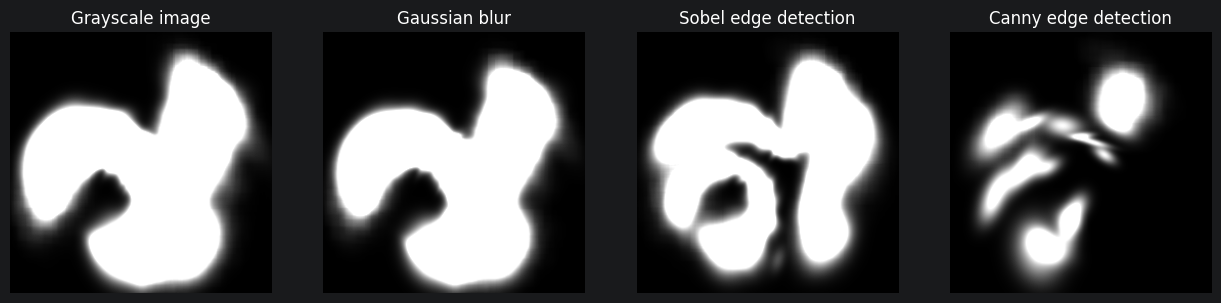

In [29]:
fig, axs = plt.subplots(1,4, figsize=(15.5,8))

# Parse each stimulation vector through the simulator
for i, stim in enumerate([stim_gray, stim_blur, stim_sobel, stim_canny]):
    simulator.reset()
    phosphenes=simulator(stim)
    axs[i].imshow(phosphenes, origin='lower', cmap='gray')

for ax in axs.flatten():
    ax.axis('off')

axs[0].set_title('Grayscale image')
axs[1].set_title('Gaussian blur')
axs[2].set_title('Sobel edge detection')
axs[3].set_title('Canny edge detection')

Both halves of each image now carry phosphenes — compare the single-nucleus notebook, where everything left of the meridian was black and a centred logo lost half its structure.

The grayscale and blur panels are still saturated. 500 electrodes per nucleus inside the 6° window sit about 0.34° apart — finer than the phosphenes they produce — so filled regions wash out and only the edge-detected inputs carry structure. Around 100–200 per nucleus is where the shape of the input survives; the size caveat from section 1 applies unchanged.

##### Final note on the stimulus sampling method..
By default, the stim amplitude equals the intensity of the sampled image. So, when working with images with pixels in range [0, 255] or [0., 1.], rescaling the pixel values to [0., *stimulus_scale*] (e.g. [0., 100.e-6] Ampère) is an important step that cannot be omitted. Unlike earlier versions of the code, rescaling needs to be incorporated *explicitly*. (Automatic rescaling is no longer the default behaviour).

As in the single-nucleus notebook, `dynaphos_lgn` does not carry the V1 simulator's `DeprecationWarning` for suspiciously high values, so the mistake is silent. The cell below prints the resulting amplitudes instead, which makes the difference obvious.

In [30]:
# Omitting the rescaling
stim = simulator.sample_stimulus(img_gray) # <- Not ok: these are pixel values, not amperes.
print(f'No rescaling      : max stim = {stim.max():.3E} A   <- ~4 decades too large')

# Using the inbuilt rescaling
stim = simulator.sample_stimulus(img_gray, rescale=True) # <- This is ok.
print(f'rescale=True      : max stim = {stim.max():.3E} A')

# Provide pixels values in range [0., 100e-6]
activation_mask = (img_gray / 255) * 100.e-6
stim = simulator.sample_stimulus(activation_mask) # <- This is also ok.
print(f'pre-scaled pixels : max stim = {stim.max():.3E} A')

No rescaling      : max stim = 8.431E-01 A   <- ~4 decades too large
rescale=True      : max stim = 8.431E-05 A
pre-scaled pixels : max stim = 8.431E-05 A


## 5. Example video

In [31]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
params['electrodes']['n_electrodes'] = 500       # per nucleus -> 1000 total
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Stop after a couple of seconds
framerate = params['run']['fps']
max_n_frames = 2*framerate

# Load the videostream
cap = cv2.VideoCapture('./example_video.mp4')
if not cap.isOpened():
    print('Unable to read file :(')

# Set the output stream. Written beside the single-nucleus notebook's
# clip rather than over it, so the two can be compared.
fourcc = cv2.VideoWriter_fourcc(*'XVID') #codec
out = cv2.VideoWriter('clip_phosphenes_lgn_bilateral.avi', fourcc, framerate,
                      (512,256), False)

# Loop over frames
frame_nr = 0
while frame_nr<max_n_frames:
    # load next frame
    ret, frame = cap.read()
    frame_nr+=1

    if not ret:
        break

    # to one channel, grayscale
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # get square if frame is not square
    if frame.shape[0] != frame.shape[1]:
        shortest_side = min(frame.shape)
        frame = frame[frame.shape[0]//2-shortest_side//2:frame.shape[0]//2+shortest_side//2,
                      frame.shape[1]//2-shortest_side//2:frame.shape[1]//2+shortest_side//2]

    # preprocess: to resize, grayscale and blur
    frame = cv2.resize(frame, (256,256))
    frame = cv2.GaussianBlur(frame, (21,21), 5)

    # edge/contour detector
    processed_img = sobel_processor(frame)
    processed_img = frame
    stim_pattern = simulator.sample_stimulus(processed_img, rescale=True)

    # Generate phosphenes
    phs = simulator(stim_pattern).clamp(0,1)
    phs = to_numpy(phs)*255

    # Concatenate results
    cat = np.concatenate([processed_img, phs], axis=1).astype('uint8')

    out.write(cat)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
print(f'Wrote clip_phosphenes_lgn_bilateral.avi ({frame_nr - 1} frames, '
      f'{n_phosphenes} electrodes over both nuclei).')

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
WARNING 3 electrodes have no usable magnification and will render with NaN size.


Wrote clip_phosphenes_lgn_bilateral.avi (69 frames, 1000 electrodes over both nuclei).


## 6. Internal parameters

In [32]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator.
# Deliberately asymmetric, to show that the two nuclei do not have to
# carry the same implant: n_electrodes is the per-nucleus default and
# n_electrodes_by_hemisphere overrides one side.
params['electrodes']['n_electrodes'] = 3
params['electrodes']['n_electrodes_by_hemisphere']['right'] = 2
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# One example frame with random stimulation
simulator.reset()
phosphenes = simulator(100e-6*torch.rand(n_phosphenes))

print(f'{n_phosphenes} electrodes: '
      + ', '.join(f'{name} {span.stop - span.start}'
                  for name, span in simulator.electrode_slices.items()))
print('hemisphere of each electrode:', list(simulator.hemisphere_of_electrode))

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


5 electrodes: left 3, right 2
hemisphere of each electrode: ['left', 'left', 'left', 'right', 'right']


#### Phosphene maps
The phosphene_maps indicate the distance in degrees of visual angle from the center of each phosphene — concatenated over both nuclei, in the same left-first order as everything else.

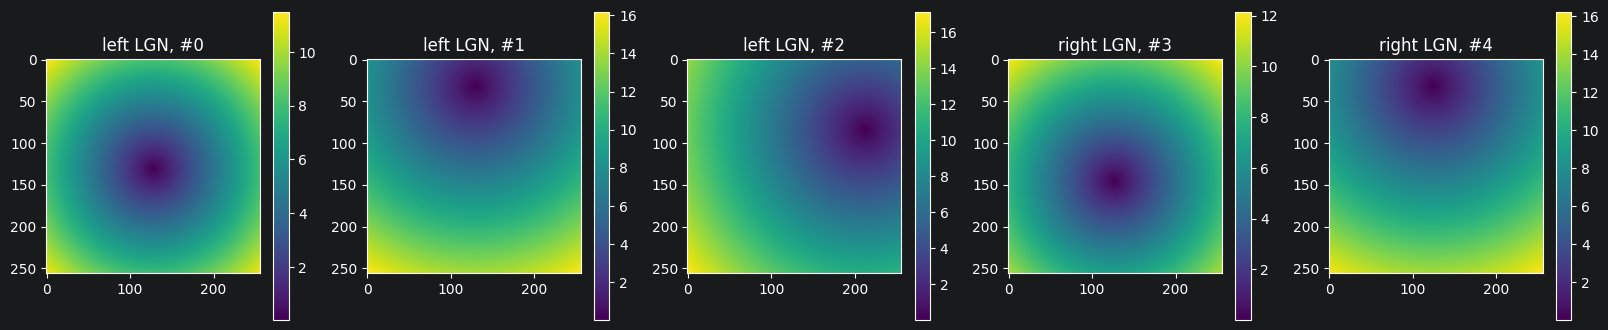

In [33]:
fig, axs= plt.subplots(1, n_phosphenes, figsize=(4*n_phosphenes, 4))
for i, ax in enumerate(axs.flatten()):
    h = ax.imshow(to_numpy(simulator.phosphene_maps[i]))
    ax.set_title(f'{simulator.hemisphere_of_electrode[i]} LGN, #{i}')
    fig.colorbar(h)

#### Internal states
Several of the simulator's internal states can be accessed, such as the *threshold*, *activation*, *brightness* and *trace*.

With two nuclei there are two of each. `get_state()` concatenates them for you; the individual state objects live on the sub-simulators, reachable through `simulator.simulators[name]`, because per-electrode thresholds are drawn independently per nucleus and reinitializing one should not touch the other.

In [34]:
# The per-nucleus state objects
for name, sub in simulator.simulators.items():
    print(f'{name:<5} LGN thresholds:', to_numpy(sub.threshold.get()).ravel())

# ... and can be reinitialized independently.
left = simulator.simulators['left']
left.threshold.reinitialize(torch.rand_like(left.threshold.get())*1e-7)
print()
for name, sub in simulator.simulators.items():
    print(f'{name:<5} LGN thresholds:', to_numpy(sub.threshold.get()).ravel())

left  LGN thresholds: [0.0000000e+00 2.1087983e-07 9.1471499e-08]
right LGN thresholds: [1.3585721e-07 2.0898423e-07]

left  LGN thresholds: [6.0089533e-08 2.5657249e-08 7.9364135e-08]
right LGN thresholds: [1.3585721e-07 2.0898423e-07]


C:\Users\sebas\PycharmProjects\dynaphos_LGN\dynaphos\utils.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, **data_kwargs)


In [35]:
# The internal states can be obtained at once using the get_state method,
# over both nuclei
all_states = simulator.get_state() # get all internal parameters
print(all_states['brightness'].shape, '<- one row per electrode, left first')
print(all_states['brightness'])

torch.Size([5, 1, 1]) <- one row per electrode, left first
tensor([[[0.4427]],

        [[0.4653]],

        [[0.1646]],

        [[0.4961]],

        [[0.1676]]])


`get_state` carries four entries the V1 simulator does not have, and they are the LGN-specific part of the model:

- `sigma_major` / `sigma_minor` — the two phosphene axes in degrees. The V1 model has one radius; here the recruitment sigma in *millimetres of tissue* is stretched by the **two principal magnifications** of the atlas's local Jacobian, so phosphenes are ellipses whose elongation and orientation come from the tissue. Reflection is orthogonal on both sides of that Jacobian, so the sizes are the same in the two nuclei and only the orientation is mirrored.
- `layer_activation` / `recruited_cells` — how much of each of the six laminae the current reached. `layer_activation_table()` is the readable view, and its rows are all the electrodes, left nucleus first.

Phosphene sigmas (deg), major vs minor:
[[0.10243016 0.00123519]
 [0.8973379  0.5504828 ]
 [0.8255117  0.5871588 ]
 [0.38117585 0.20708302]
 [0.68018174 0.29147887]]


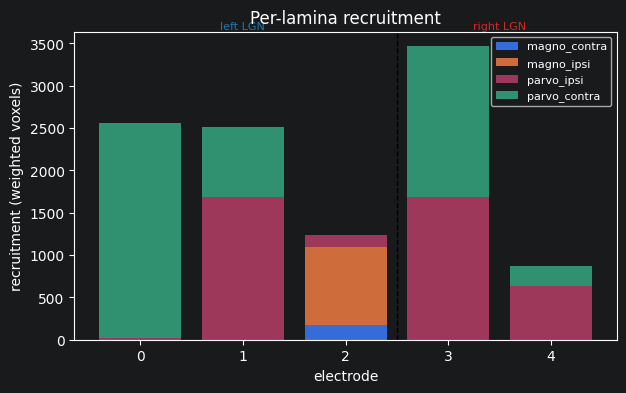

In [36]:
# Per-lamina recruitment for the last frame, over both nuclei
table = simulator.layer_activation_table()

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(simulator.num_phosphenes)
bottom = np.zeros(simulator.num_phosphenes)
for name, values in table.items():
    values = np.atleast_1d(values).ravel()
    ax.bar(x, values, bottom=bottom, label=name)
    bottom = bottom + values

# Mark where one nucleus ends and the other begins
for name, span in simulator.electrode_slices.items():
    if span.start:
        ax.axvline(span.start - 0.5, color='k', lw=1.0, ls='--')
    ax.text((span.start + span.stop - 1) / 2, ax.get_ylim()[1],
            f'{name} LGN', ha='center', va='bottom', fontsize=8,
            color=HEMISPHERE_COLOURS[name])
ax.set(xlabel='electrode', ylabel='recruitment (weighted voxels)',
       title='Per-lamina recruitment')
ax.legend(fontsize=8)

print('Phosphene sigmas (deg), major vs minor:')
print(np.stack([to_numpy(all_states['sigma_major']).ravel(),
                to_numpy(all_states['sigma_minor']).ravel()], axis=-1))

## 7. Computational optimization
The simulation framework is created in pytorch and makes use of differentiable operations to enable computational optimization.

Note: The code below is an extremely simplified 'mock example' of computational optimization of the stimulation parameters. It is *not* part of the end-to-end optimization paradigm used in the experiments of the publication. That end-to-end optimization framework can be found in [**this repository**](https://github.com/neuralcodinglab/viseon/tree/dynaphos-paper).

Gradients cross the nucleus boundary the same way the percept does: the two sub-simulators are summed into one image, so one loss backpropagates into both arrays' amplitudes.

#### Mock example of computational optimization

In [37]:
# Load the simulator configuration file
params = utils.load_params('../config/params_lgn.yaml')
params['atlas']['hemispheres'] = ['left', 'right']
params['thresholding']['soft_threshold'] = True   # pinned, not inherited
params['electrodes']['max_eccentricity_deg'] = 6.0

# Get electrode locations and initialize simulator
params['electrodes']['n_electrodes'] = 3         # per nucleus -> 6 total
simulator, parts = build_simulator(params, atlas_dir=ATLAS_DIR)
n_phosphenes = simulator.num_phosphenes

# Optimization target. `simulator.shape` spans both nuclei, so this
# broadcasts against what get_state() returns.
target_brightness = 0.5 * torch.ones(simulator.shape)

# Initialize an 'encoder' which will be optimized
# (note: not using a real DNN encoder here, but just a tensor that scales the stimulation)
base_stim = 100e-6 * torch.ones(n_phosphenes)
encoder = torch.nn.Parameter(torch.rand(n_phosphenes), requires_grad=True)
optimizer = torch.optim.Adam([encoder],lr=0.05)
print(encoder)

INFO Loading cached Jacobian atlas from ..\data\Erwin_Atlas\JACOBIAN.npz.
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).
INFO Candidate neighbourhood: 6667 voxels per electrode (stride 2, radius 0.584 mm at I_max = 100.0 uA).


Parameter containing:
tensor([0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009], requires_grad=True)


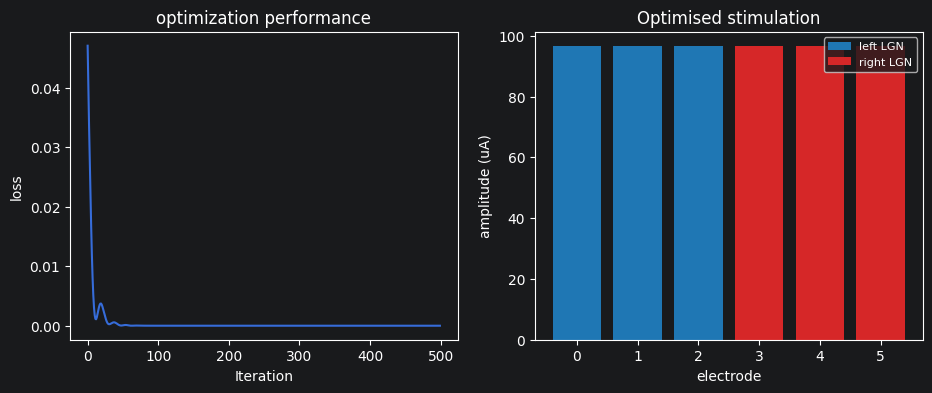

Parameter containing:
tensor([0.9648, 0.9648, 0.9648, 0.9648, 0.9648, 0.9648], requires_grad=True)


In [38]:
# Track optimization performance
hist = {'brightness': [],
        'stim': [],
        'encoder': [],
        'loss': []}

# Iteratively update the 'encoder'
for _ in range(500):
    optimizer.zero_grad()
    simulator.reset()
    stim = base_stim * encoder
    phosphenes = simulator(stim)
    brightness = simulator.get_state()['brightness']
    mse = torch.nn.functional.mse_loss(brightness, target_brightness)
    mse.backward()
    optimizer.step()

    # Track optimization performance
    hist['stim'].append(stim.detach().clone())
    hist['encoder'].append(encoder.detach().clone())
    hist['brightness'].append(brightness.detach().clone())
    hist['loss'].append(mse.item())

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(hist['loss'])
axs[0].set(xlabel='Iteration', ylabel='loss', title='optimization performance')

# The stimulation the optimiser found, by nucleus
final = to_numpy(hist['stim'][-1]).ravel()
for name, span in simulator.electrode_slices.items():
    axs[1].bar(np.arange(span.start, span.stop), final[span] * 1e6,
               color=HEMISPHERE_COLOURS[name], label=f'{name} LGN')
axs[1].set(xlabel='electrode', ylabel='amplitude (uA)',
           title='Optimised stimulation')
axs[1].legend(fontsize=8)
plt.show()

print(encoder)

#### Gradients reach both nuclei
Worth checking rather than assuming, since the percept is a sum over two independent state machines: if the sum were done wrongly — clamped per nucleus, or detached — one array would silently stop learning.

In [39]:
simulator.reset()
probe = torch.full((n_phosphenes,), 80e-6, requires_grad=True)
simulator(probe).sum().backward()

for name, span in simulator.electrode_slices.items():
    grad = probe.grad[span]
    print(f'{name:<5} LGN: |dLoss/dAmplitude| sum = {float(grad.abs().sum()):.4E}')

left  LGN: |dLoss/dAmplitude| sum = 1.1623E+07
right LGN: |dLoss/dAmplitude| sum = 3.7624E+06


One thing the LGN config does differently is worth stating, because it is a model change and not a solver trick. `thresholding.soft_threshold` is **on** by default: the detection gate is a logistic psychometric curve rather than Dynaphos's hard step. With a hard threshold, an electrode below threshold has exactly zero gradient and can never learn to cross it — which is precisely the electrode an optimiser most needs to move. Set `params['thresholding']['soft_threshold'] = False` to recover the V1 behaviour, and say which one you used when reporting.

Gradients reach amplitude, pulse width and frequency through the image, the recruitment weights and the activation state, in both nuclei. They do **not** reach voxel positions or layer labels: those are fixed buffers, so electrode *placement* is not optimisable here. Nor does anything couple the two nuclei — there is no binocular or interhemispheric interaction in this model at all (see the README's known gaps).